## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('EV_train.csv')
test = pd.read_csv('EV_test.csv')
sample_submission = pd.read_csv('EV_sample_submission.csv')

target = "Will_Buy_EV"
train[target] = train[target].map({'No' : 0,
                                    'Yes' : 1
})

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train Shape: (668665, 15)
Test Shape: (286571, 14)
Sample Submission Shape: (286571, 2)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


### Target Distribution

In [2]:
target_counts = (train[target].value_counts())
target_proportion = (train[target].value_counts(normalize=True))

target_summary = pd.merge(target_counts, target_proportion, on=target)
display(target_summary)

,count,proportion
Will_Buy_EV,,
0,551886,0.825355
1,116779,0.174645


### Dataset Features

In [3]:
features = [column for column in test.columns if column != 'id']
print("Number Of Featrues:", len(features))

numerical_features = train[features].select_dtypes(include='number').columns.tolist()
print('Numerical Features:')
print(numerical_features)

print()

categorical_features = train[features].select_dtypes(exclude='number').columns.tolist()
print('Categorical Features:')
print(categorical_features)

Number Of Featrues: 13
Numerical Features:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical Features:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


### Missing Summary

In [4]:
def MissingSummary(x):
    return pd.DataFrame({'Missing Count' : x.isna().sum(),
                        'Missing Mean' : x.isna().mean()
    })

train_missing = MissingSummary(train[features])
test_missing = MissingSummary(test[features])

missing = pd.concat([train_missing.add_prefix('Train'), test_missing.add_prefix('Test')], axis=1)
display(missing)

,TrainMissing Count,TrainMissing Mean,TestMissing Count,TestMissing Mean
Age,0,0.0,0,0.0
Annual_Income_USD,0,0.0,0,0.0
Daily_Commute_km,0,0.0,0,0.0
Number_of_Cars_Owned,0,0.0,0,0.0
Charging_Stations_Near_Home,0,0.0,0,0.0
Charging_Stations_Near_Work,0,0.0,0,0.0
Environmental_Concern_Level,0,0.0,0,0.0
Gender,0,0.0,0,0.0
City_Type,0,0.0,0,0.0
Current_Car_Type,0,0.0,0,0.0


### Categorical Labels And Numerical Features

In [5]:
print("Categorical Featres:")
for column in categorical_features:
    categories = set(train[column].unique())
    print(column,":", sorted(categories))

print()
print("Numerical Features:")
display(train[numerical_features].describe().transpose().round(3))

Categorical Featres:
Gender : ['Female', 'Male', 'Other']
City_Type : ['Rural', 'Suburban', 'Urban']
Current_Car_Type : ['Hatchback', 'SUV', 'Sedan', 'Truck']
Home_Charging_Possible : ['No', 'Yes']
Subsidy_Available : ['No', 'Yes']
Range_Anxiety_Level : ['High', 'Low', 'Medium']

Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039,12.875,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.267,28648.029,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158,18.730,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.713,0.729,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960,3.927,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176,5.187,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935,1.429,1.0,2.0,3.0,4.0,5.0


### Numerical Correlation

In [6]:
numerical_correlation = (train[numerical_features].corrwith(train[target])).sort_values(ascending=False)
display(numerical_correlation)

Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
dtype: float64

### Categorical Features

In [7]:
categoricalsummaries = []

for feature in categorical_features:
    categoricaldata = train[[feature, target]].copy()
    categoricaldata[feature] = categoricaldata[feature].fillna('missing')

    categoricalsummary = (categoricaldata.groupby(feature, dropna=False)
                          .agg(size=(target, 'size'), average=(target, 'mean'))
                          .reset_index())
    categoricalsummary = categoricalsummary.rename(columns={feature : 'category'})

    categoricalsummary.insert(0, 'feature', feature)
    categoricalsummaries.append(categoricalsummary)


categoricalsummaries = pd.concat(categoricalsummaries)    
categoricalsummaries

,feature,category,size,average
0,Gender,Female,295427,0.177641
1,Gender,Male,367954,0.172253
2,Gender,Other,5284,0.173732
0,City_Type,Rural,123983,0.193389
1,City_Type,Suburban,255377,0.180936
2,City_Type,Urban,289305,0.161058
0,Current_Car_Type,Hatchback,79438,0.174299
1,Current_Car_Type,SUV,246545,0.180953
2,Current_Car_Type,Sedan,303459,0.171967
3,Current_Car_Type,Truck,39223,0.156413


## Summary
Features with the most impact: Enviromental Concern, Income, Range_Anxiety, Subsidies, Home_Charging

## Findings
### What if there's no nearby charging stations near home or work?

In [8]:
train['No_Charging'] = (
    (train['Charging_Stations_Near_Home'] == 0) &
    (train['Charging_Stations_Near_Work'] == 0)
).astype(int)

out = train[train['No_Charging'] == 1]
print("Shape of Output:", out.shape)
print(f"Percent of Ppl with No Charging {len(out)/len(train)*100:.2f}%")
display(out.head())
print(out.Will_Buy_EV.value_counts(normalize=True) * 100)

Shape of Output: (8819, 16)
Percent of Ppl with No Charging 1.32%


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,No_Charging
22,22,50,97680.0,25.4,1,0,0,5.0,Female,Rural,SUV,Yes,Yes,Low,0,1
34,34,28,77366.0,32.0,2,0,0,2.0,Female,Rural,Sedan,Yes,Yes,Low,0,1
206,206,62,121657.0,33.6,2,0,0,2.0,Male,Rural,Hatchback,Yes,No,Low,0,1
276,276,61,56563.0,21.3,4,0,0,1.0,Male,Rural,Hatchback,Yes,No,Low,0,1
333,333,69,30000.0,5.0,2,0,0,3.0,Female,Rural,Sedan,Yes,No,Low,0,1


Will_Buy_EV
0    81.789319
1    18.210681
Name: proportion, dtype: float64


This Suggests that charging accessibility plays an important factor. But why do ppl still buy them?

In [9]:
no_nearby_buyers = train[
    (train['No_Charging'] == 1) &
    (train['Will_Buy_EV'] == 1)
]
print("Shape:", no_nearby_buyers.shape)

#consider subsidies

mask = train['No_Charging'] == 1

buyers = train.loc[
    mask & (train['Will_Buy_EV'] == 1), 'Subsidy_Available'
]

result = buyers.value_counts().to_frame('Yes Count')
result['Yes Percentage'] = (
    result['Yes Count']/result['Yes Count'].sum() * 100
).round(2)
display(result)

Shape: (1606, 16)


,Yes Count,Yes Percentage
Subsidy_Available,,
Yes,1577,98.19
No,29,1.81


### Effect of Subsidy and Home Charging

In [10]:
yes_yes = train[(train['Subsidy_Available'] == 'Yes') &
    (train['Home_Charging_Possible'] == 'Yes')
][target].value_counts()

no_no = train[(train['Subsidy_Available'] == 'No') &
    (train['Home_Charging_Possible'] == 'No')
][target].value_counts()

yes_yes_result = pd.DataFrame({'Count' : yes_yes,
    'Percentage': (yes_yes / yes_yes.sum() * 100).round(2)
})

print('Subsidy and Homecharging: Yes')
display(yes_yes_result)

no_no_result = pd.DataFrame({'Count' : no_no,
    'Percentage' : (no_no / no_no.sum() * 100).round(2)
})

print('Subsidy and Homecharging: No')
display(no_no_result)

Subsidy and Homecharging: Yes


,Count,Percentage
Will_Buy_EV,,
0,204931,69.6
1,89494,30.4


Subsidy and Homecharging: No


,Count,Percentage
Will_Buy_EV,,
0,80179,99.6
1,325,0.4


### Why Do These Ppl Still Buy EVs?

In [11]:
no_no_buyers = train[(train['Subsidy_Available'] == 'No') &
    (train['Home_Charging_Possible'] == 'No') &
    (train[target] == 1)
]
print("Shape of No No Buyers:", no_no_buyers.shape)

display(no_no_buyers['Environmental_Concern_Level'].value_counts())
display(no_no_buyers['Range_Anxiety_Level'].value_counts())

Shape of No No Buyers: (325, 16)


Environmental_Concern_Level
5.0    206
4.0     74
3.0     38
2.0      4
1.0      3
Name: count, dtype: int64

Range_Anxiety_Level
Low       302
Medium     23
Name: count, dtype: int64

Effect of Income on EV buying

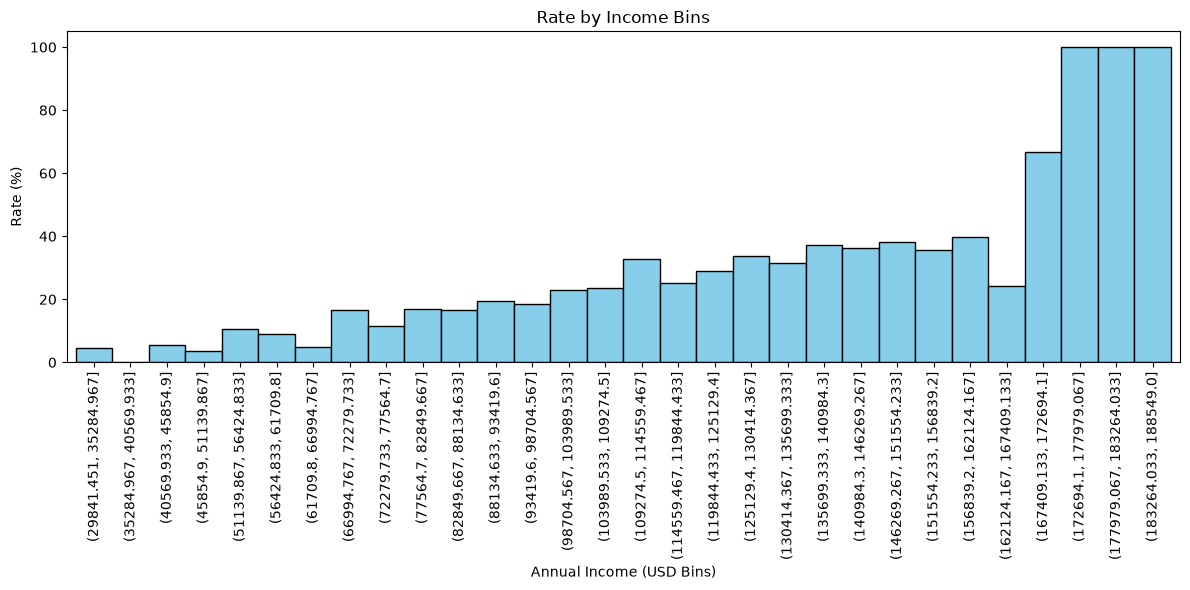

In [12]:
income_bins = pd.cut(train['Annual_Income_USD'], bins=30)
income_rate = train.groupby(income_bins)[target].apply(lambda x: (x == 1).mean() * 100 ).reset_index()

ax = income_rate.set_index("Annual_Income_USD")[target].plot(
    kind="bar", width=1.0, edgecolor="black", figsize=(12, 6), color="skyblue"
)

plt.xlabel("Annual Income (USD Bins)")
plt.ylabel("Rate (%)")
plt.title("Rate by Income Bins")
plt.tight_layout()
plt.show()

At a certain income EV Purchases become 100% and EV Purchase falls to Zero at a certain range

Effect of Range

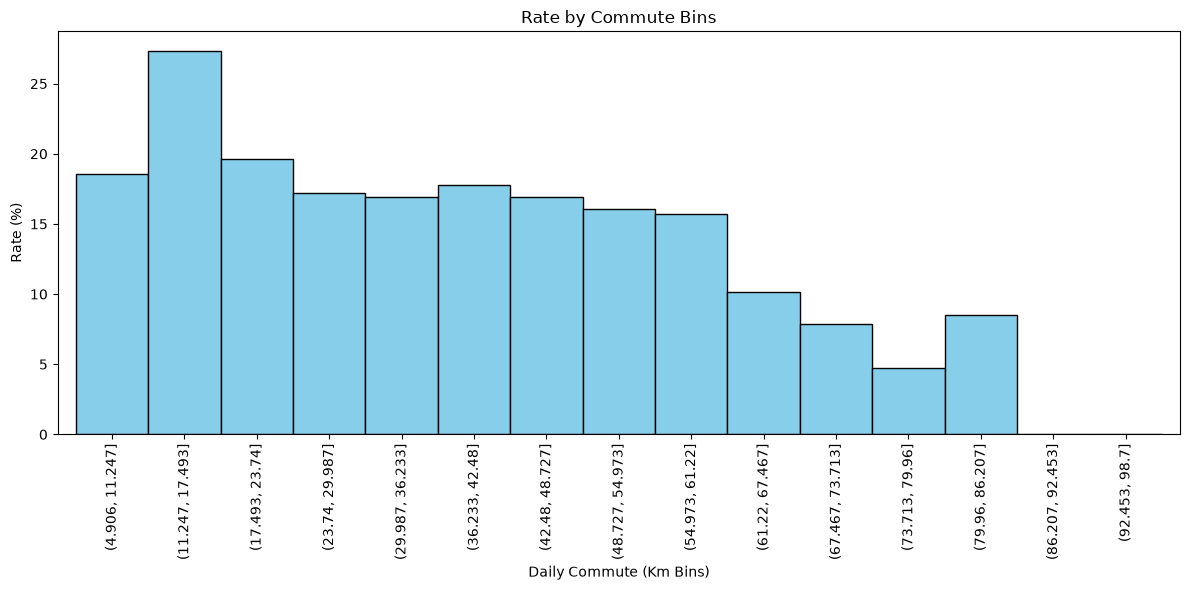

In [14]:
range_bins = pd.cut(train['Daily_Commute_km'], bins=15)
range_rate = train.groupby(range_bins)[target].apply(lambda x: (x == 1).mean() * 100 ).reset_index()

ax = range_rate.set_index("Daily_Commute_km")[target].plot(
    kind="bar", width=1.0, edgecolor="black", figsize=(12, 6), color="skyblue"
)

plt.xlabel("Daily Commute (Km Bins)")
plt.ylabel("Rate (%)")
plt.title("Rate by Commute Bins")
plt.tight_layout()
plt.show()

EV purchase drops to 0 after 86 km

### Relationship between Range Anxiety and Daily Commute

In [15]:
out = train.groupby('Range_Anxiety_Level')['Daily_Commute_km'].mean()
display(out)
#Note more range anixety = less likely to buy even

Range_Anxiety_Level
High      52.916591
Low       31.005896
Medium    42.566057
Name: Daily_Commute_km, dtype: float64

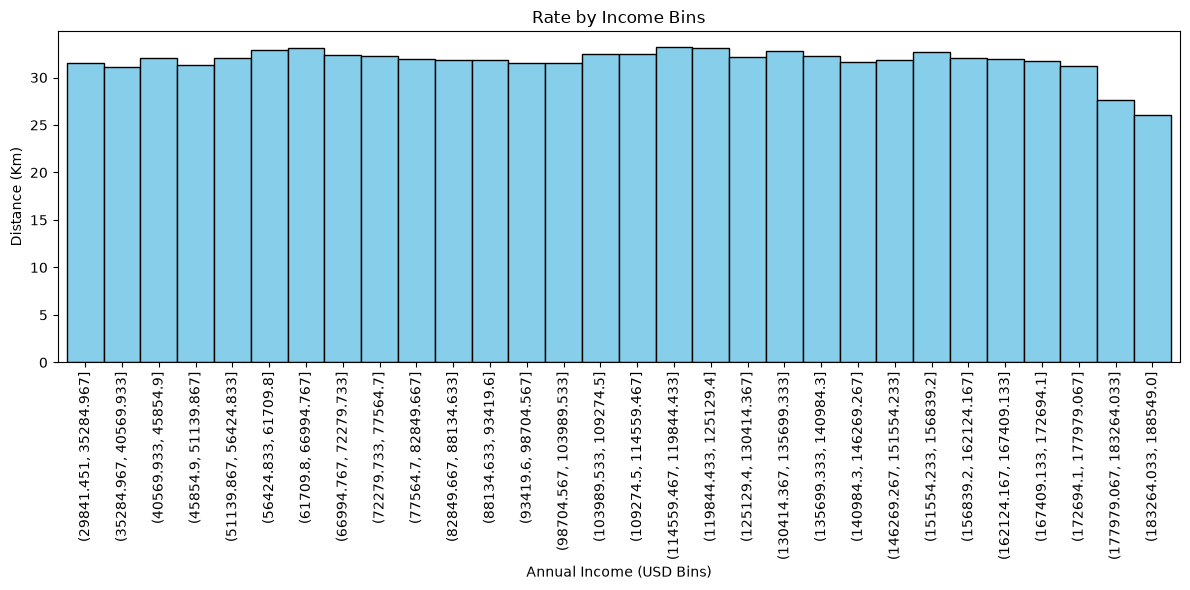

In [16]:
#Consider commute and income
income_commute = train.groupby(income_bins)['Daily_Commute_km'].mean()
income_commute.plot(
    kind="bar", width=1.0, edgecolor="black", figsize=(12, 6), color="skyblue"
)

plt.xlabel("Annual Income (USD Bins)")
plt.ylabel("Distance (Km)")
plt.title("Rate by Income Bins")
plt.tight_layout()
plt.show()

##Income and Distance doesn't hit a ceiling where ppl don't buy evs

## Feature Engineering

In [17]:
#Charging Infastruce(Infastruce doesn't seem to have a lot of impact)
train['Total_Charging_Stations'] = train['Charging_Stations_Near_Work'] + train['Charging_Stations_Near_Home']

train['Charging_Station_Diff'] = train['Charging_Stations_Near_Work'] - train['Charging_Stations_Near_Home']

train['Charging_Both_Locations'] = (
    (train['Charging_Stations_Near_Home'] > 0) % (train['Charging_Stations_Near_Work'] > 0)
)

In [18]:
#Anxiety
range_anxiety_rank = train["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})

train["RangeAnxiety_x_EnvConcern_num"] = (
    (2 - range_anxiety_rank) * train["Environmental_Concern_Level"]
)
train["RangeAnxiety_EnvConcern"] = (
    train["Range_Anxiety_Level"].astype(str)
    + "_env"
    + train["Environmental_Concern_Level"].astype(int).astype(str)
)

train["Subsidy_RangeAnxiety"] = (
    train["Subsidy_Available"].astype(str) + "_" + train["Range_Anxiety_Level"].astype(str)
)
train["Subsidy_HomeCharging"] = (
    train["Subsidy_Available"].astype(str) + "_" + train["Home_Charging_Possible"].astype(str)
)

In [ ]:
#Affordability
train['Income_Per_Car'] = train['Annual_Income_USD'] / train['Number_of_Cars_Owned']

train['Income_Per_Commute'] = train['Annual_Income_USD'] / train['Daily_Commute_km']

train['Income_X_Subsidy'] = income_bins.astype(str) + '_' + train['Subsidy_Available'] #try

In [20]:
#Behavioral Interactions
train['EnvConcern_X_DailyCommute'] = train['Environmental_Concern_Level'] * train['Daily_Commute_km']

train['EnvConcern_X_Subsidy'] = train['Environmental_Concern_Level'].astype(str) + '_' + train['Subsidy_Available'].astype(str)